# CO543: Image Processing - Lab 5 (2025)

## Edges, Corners & Structural Features
## E/21/245


### Task 1 — Detect Edges Using Gradient Operators

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [21]:
# Load the image and convert it to Grayscale value

img = cv2.imread('Sample.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [22]:
# Apply the Sobel Operator ( First - Order)
# Sobel X (detects vertical edges)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)

In [23]:
# Sobal Y this detects horizontal edges
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)


In [25]:
# combin the sobal y and the sobal x to see teh edges
sobel_combined = cv2.magnitude(sobelx, sobely)

In [27]:
# Apply the  Laplacian Operator (second - order)
laplacian = cv2.Laplacian(gray, cv2.CV_64F)

In [29]:
# convert absolute values fo r to the displaying
sobelx_abs = cv2.convertScaleAbs(sobelx)
sobely_abs = cv2.convertScaleAbs(sobely)
sobel_combined_abs = cv2.convertScaleAbs(sobel_combined)
lap_abs = cv2.convertScaleAbs(laplacian)

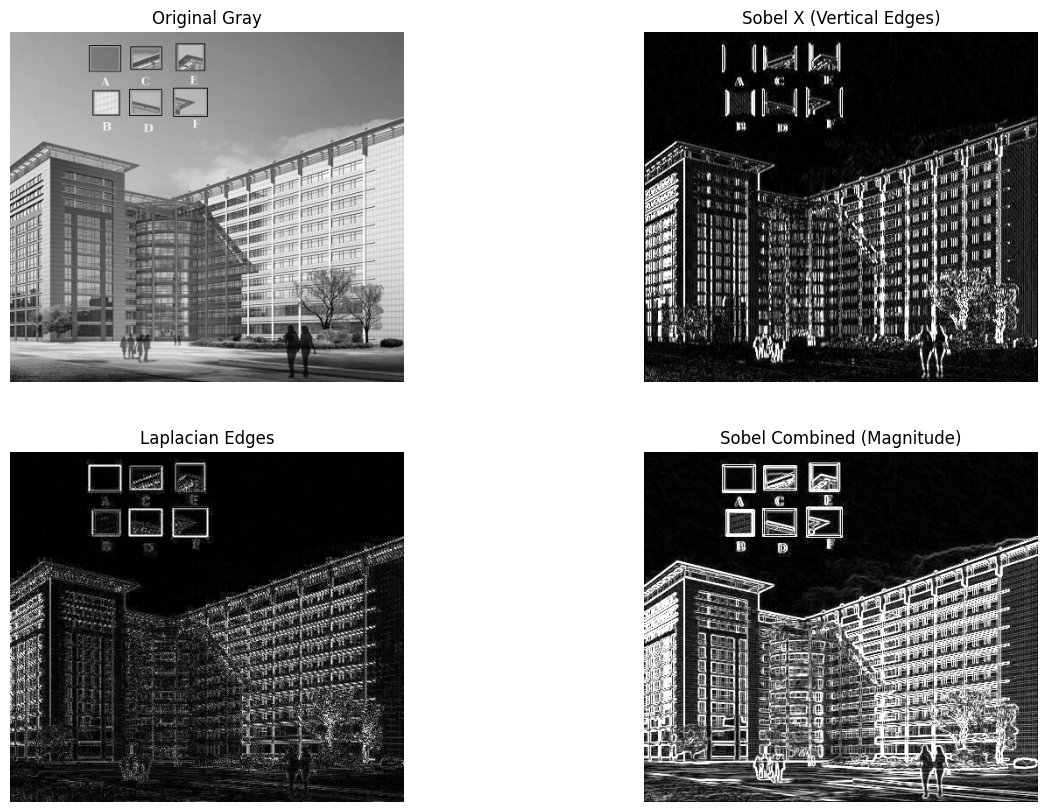

In [30]:
# Display the results
plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1), plt.imshow(gray, cmap='gray'), plt.title('Original Gray')
plt.axis('off')

plt.subplot(2, 2, 2), plt.imshow(sobelx_abs, cmap='gray'), plt.title('Sobel X (Vertical Edges)')
plt.axis('off')

plt.subplot(2, 2, 3), plt.imshow(lap_abs, cmap='gray'), plt.title('Laplacian Edges')
plt.axis('off')

plt.subplot(2, 2, 4), plt.imshow(sobel_combined_abs, cmap='gray'), plt.title('Sobel Combined (Magnitude)')
plt.axis('off')

plt.show()


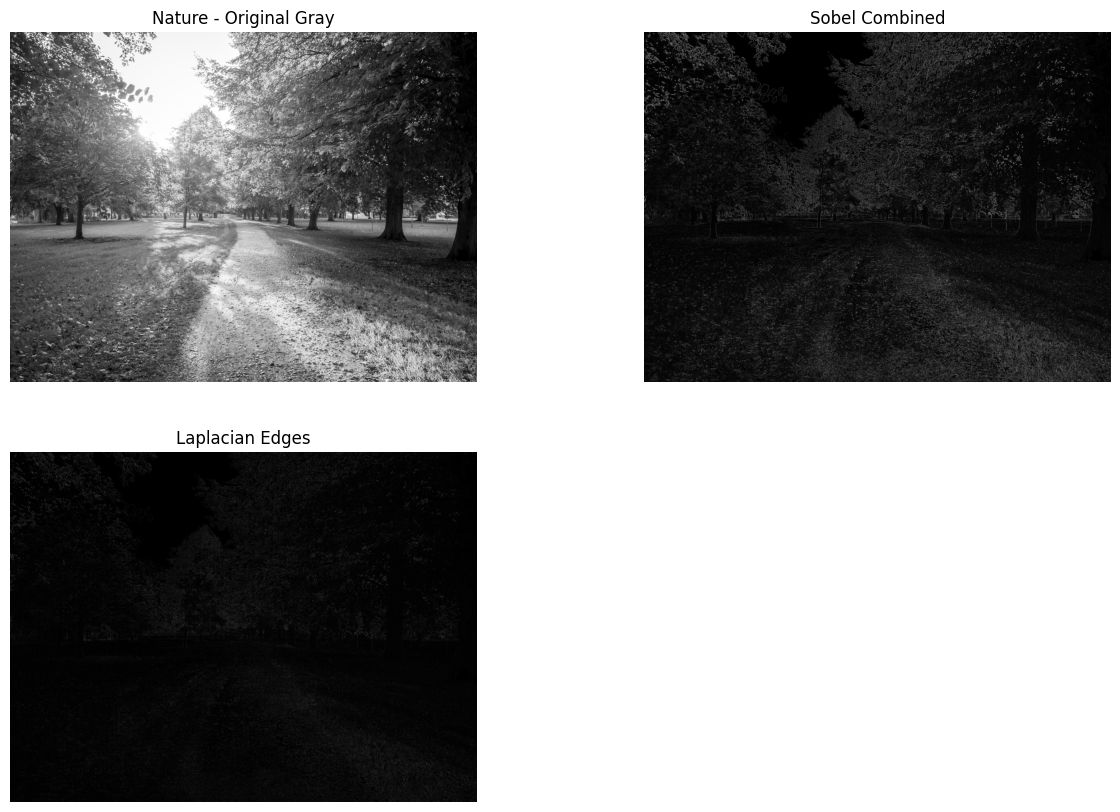

In [31]:

# Load the nature image and convert to Grayscale
img_nature = cv2.imread('nature.jpg')
gray_nature = cv2.cvtColor(img_nature, cv2.COLOR_BGR2GRAY)

#  Apply Sobel Operator
sobelx = cv2.Sobel(gray_nature, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_nature, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

# Apply Laplacian Operator
lap = cv2.Laplacian(gray_nature, cv2.CV_64F)

#  Display Results
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1), plt.imshow(gray_nature, cmap='gray'), plt.title('Nature - Original Gray')
plt.axis('off')

plt.subplot(2, 2, 2), plt.imshow(sobel_combined, cmap='gray'), plt.title('Sobel Combined')
plt.axis('off')

plt.subplot(2, 2, 3), plt.imshow(np.abs(lap), cmap='gray'), plt.title('Laplacian Edges')
plt.axis('off')

plt.show()

#### Observations: Man-Made Image (Building)
In the building image, the structures are geometric and predictable.

- Sobel Operator: Provides very clean and smooth results. It emphasizes the long, straight lines of the building walls and the sharp vertical columns. Because it uses Gaussian smoothing, the results are stable and easy to see.

- Laplacian Operator: Highlights the outlines of the building but is much more sensitive. It detects the fine textures on the windows and the wall patterns, making the building look like a detailed technical drawing.

#### Observations: Nature Image (Trees and Path)
In the nature image, the features are organic and complex.

- Sobel Operator: This filter struggles more here. Instead of clear lines, it creates "blobs" or clusters of edges because the trees and leaves don't have long, continuous straight lines.

- Laplacian Operator: This image looks very dark or "noisy" because the Laplacian is picking up every tiny change in the leaves and grass. It emphasizes the high-frequency texture of the foliage rather than the

#### More to think: Why does the Laplacian respond strongly at both sides of an edge while Sobel gives direction?

Sobel (1st Derivative): Measures the slope (gradient) of intensity. It has a single peak at the edge, where the sign (+ or -) indicates the direction of the change (e.g., light-to-dark).

Laplacian (2nd Derivative): Measures the curvature (change in slope). It responds strongly on both sides because it creates a positive peak and a negative peak, crossing zero at the exact center of the edge (known as a zero-crossing).

### Task 2 — Detect Clean Boundaries with Canny

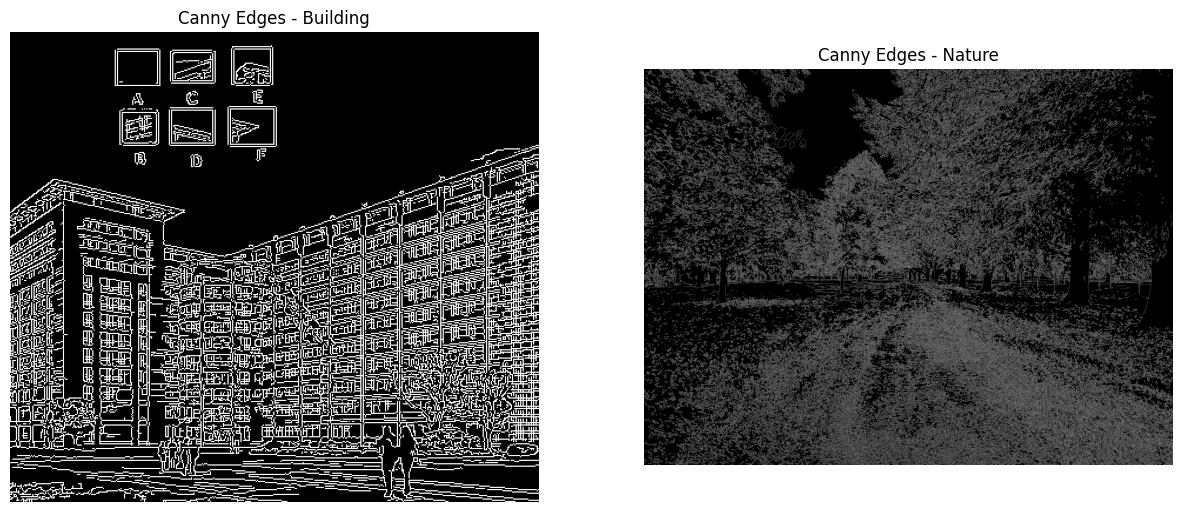

In [32]:
# Apply Canny Edge Detection
# Threshold 1 = 50, Threshold 2 = 150
edges_building = cv2.Canny(gray, 50, 150)
edges_nature = cv2.Canny(gray_nature, 50, 150)

# Display Results
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(edges_building, cmap='gray')
plt.title('Canny Edges - Building')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edges_nature, cmap='gray')
plt.title('Canny Edges - Nature')
plt.axis('off')
plt.show()

#### Discussion

- The Problem: Sobel/Laplacian create "thick" edges because they highlight the entire gradient slope.

- The Solution: Canny uses Non-Maximum Suppression, which keeps only the local maximum pixel along the edge direction, thinning the boundary to a single-pixel width.

##### Thresholds and Noise Suppression

- Double Thresholding: Using 50 and 150 filters the image.

- High Threshold (150): Only strong gradients (true edges) are accepted, removing soft textures.

- Low Threshold (50): Anything below this is discarded as noise.

- The Result: This removes the "grainy" noise seen in Laplacian and keeps only structural boundaries.

##### More to Think: Hysteresis Thresholding

- Question: How does hysteresis thresholding assist in avoiding broken edges?

- Answer: Hysteresis thresholding acts as a "connector." If an edge pixel has an intensity between the low (50) and high (150) thresholds, it is usually in a "gray area." Hysteresis tells the computer: "Keep this pixel only if it is connected to a strong edge (above 150)." This prevents long edges, like the roof of the building, from breaking into dashed lines just because the lighting changed slightly along the path. It ensures edge continuity.

### Task 3 — Locate Corner Features

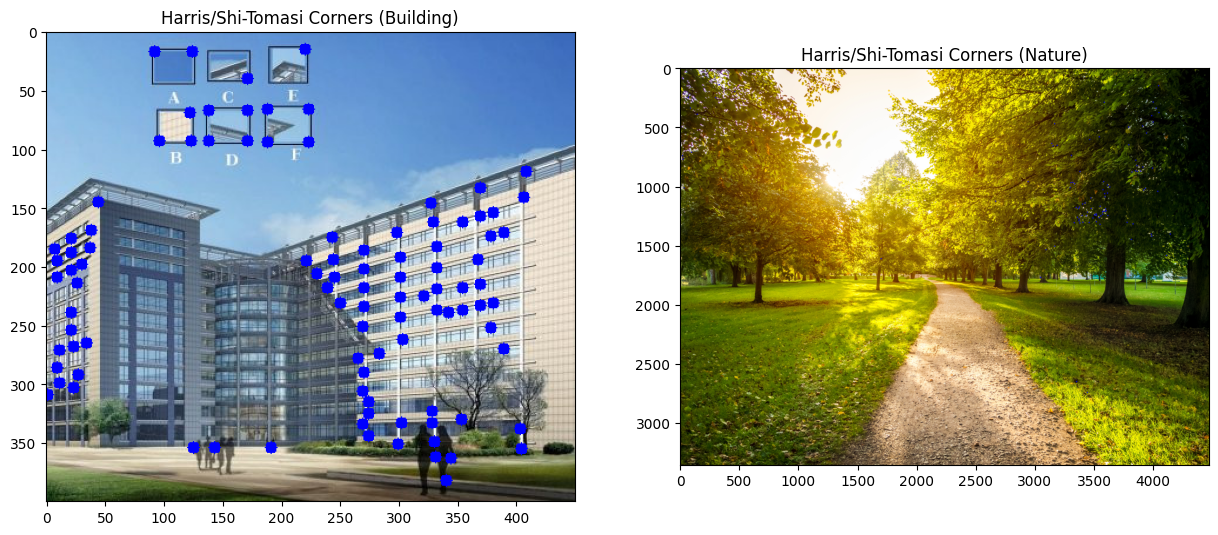

In [33]:
# Detect corners
# (image, maxCorners, qualityLevel, minDistance)
corners_b = cv2.goodFeaturesToTrack(gray, 100, 0.01, 10)
corners_n = cv2.goodFeaturesToTrack(gray_nature, 100, 0.01, 10)

# Mark corners on building image
img_corners_b = img.copy()
for i in corners_b:
    x, y = i.ravel()
    cv2.circle(img_corners_b, (int(x), int(y)), 5, (255, 0, 0), -1)

# Mark corners on nature image
img_corners_n = img_nature.copy()
for i in corners_n:
    x, y = i.ravel()
    cv2.circle(img_corners_n, (int(x), int(y)), 5, (255, 0, 0), -1)

# Display
plt.figure(figsize=(15, 7))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img_corners_b, cv2.COLOR_BGR2RGB)), plt.title('Harris/Shi-Tomasi Corners (Building)')
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(img_corners_n, cv2.COLOR_BGR2RGB)), plt.title('Harris/Shi-Tomasi Corners (Nature)')
plt.show()

#### Observations
- Building Image: Corners are highly concentrated on structured areas like window frames, roof edges, and pillars. These points are very stable and easy to track.
- Nature Image: Corners are more scattered and less predictable because they appear on irregular shapes like leaf tips and branch intersections.
- Visualization: While the detection was performed on grayscale images, the results are marked in blue on the original color image to make the detected "interest points" clearly visible to the reader.
- Why Corners are Valuable
- Corners are unique 2D landmarks that can be assigned exact $(x, y)$ coordinates.
- They remain stable even if the camera angle or lighting changes slightly, making them perfect for image matching and motion tracking.

#### More to think: Why are corners more distinctive than straight edges?

- Ambiguity: Straight edges suffer from the "Aperture Problem," meaning if you look at a line through a small window, you cannot tell if it is moving along its own axis.

- 2D Information: An edge only shows change in one direction, but a corner shows change in two directions. This makes a corner a unique point in space, whereas an edge could be any point along a line, making corners much more reliable for recognizing specific objects.

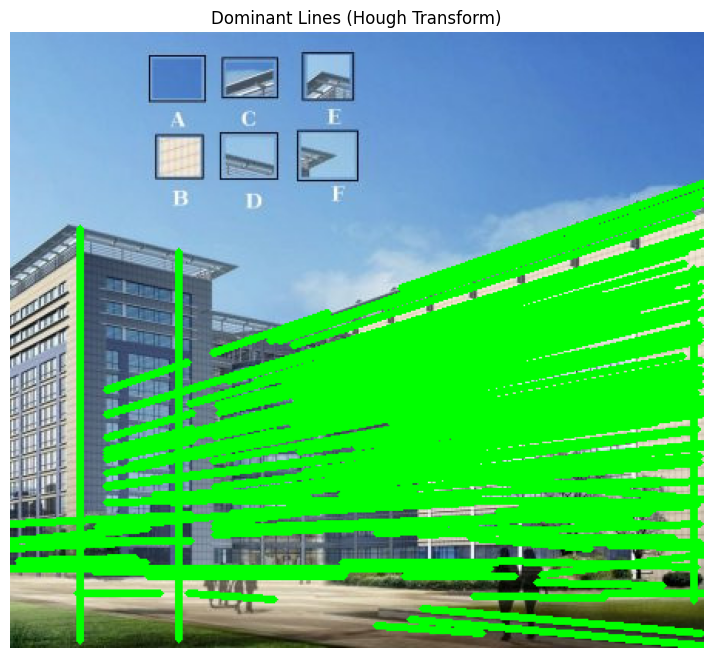

In [34]:
# Apply Probabilistic Hough Transform
# (image, rho, theta, threshold, minLineLength, maxLineGap)
lines = cv2.HoughLinesP(edges_building, 1, np.pi/180, 150, minLineLength=50, maxLineGap=10)

# Draw lines on the building image
img_lines = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 3)

# Display Result
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title('Dominant Lines (Hough Transform)')
plt.axis('off')
plt.show()

#### Observations from Results

- Man-Made Structure: In image_3761a5.jpg, the Hough Transform successfully identified the strong horizontal and vertical geometric patterns of the building. The green lines perfectly align with the structural floors and columns, effectively capturing the building’s perspective.

- Effect of Vote Threshold: My results show a large number of overlapping lines. This indicates that the current vote threshold might be set too low. While a low threshold ensures no structural line is missed, it also causes "redundancy," where multiple line segments are detected for the same physical edge. Increasing the threshold would filter out these weaker overlaps, leaving only the most "dominant" architectural boundaries.

#### More to Think: Could detecting too many edges or lines make interpretation harder?

Yes. As seen in my output image, detecting too many lines leads to visual clutter.

Interpretability: When every minor detail or shadow is detected as a line, the high-level "shape" of the building becomes obscured.

Computational Cost: For an autonomous system (like a self-driving car or a drone), processing thousands of redundant lines is inefficient.

The Goal: Feature extraction should aim for sparsity. A clearer interpretation is achieved when only the "skeleton" of the object is detected, rather than every possible gradient change.

### Final reflection

Structural cues like edges, corners, and lines serve as the "digital DNA" for advanced computer vision tasks. Edges provide the foundational boundaries needed for mapping environments, allowing systems to define the physical limits of objects. Corners act as unique, repeatable landmarks that are essential for image stitching and object tracking; because they are distinctive 2D points, algorithms can precisely match them across different photos or video frames even if the camera moves or the lighting changes. Finally, dominant lines simplify complex scenes into mathematical structures, helping systems understand perspective and orientation. Together, these features transform raw pixel data into a structured geometric map that a machine can interpret and follow.